In [1]:
# Vaihe 4: Mallien koulutus
# Alustus: importit + datan lataus

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lataa Vaiheen 3 lopullinen välitallennus
setups_with_features = pd.read_parquet(
    '../data/processed/setups_with_features.parquet'
)

print(f"Rivejä: {len(setups_with_features):,}")
print(f"Sarakkeita: {len(setups_with_features.columns)}")
print(f"Sarakkeet: {list(setups_with_features.columns)}")

Rivejä: 8,281
Sarakkeita: 34
Sarakkeet: ['setup_id', 'symbol', 'date', 'direction', 'setup_index_in_day', 'box_high', 'box_low', 'box_mid', 'entry_time', 'entry_price', 'stop_loss', 'take_profit', 'risk_reward_ratio', 'outcome_time', 'outcome', 'label', 'date_only', 'entry_outside_box', 'entry_position_in_box', 'hour_sin', 'hour_cos', 'prev_day_range_pct', 'box_size_vs_atr14d', 'ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned', 'volume_vs_ma20_15m', 'rsi_1h', 'atr_15m_vs_atr_daily', 'atr_1h_pct', 'reversal_candle_time', 'reversal_candle_size_pct', 'minutes_in_opposite_half']


In [2]:
# Mallinnukseen vain labeled-setupit (expired-setupit pois)
df_ml = setups_with_features[setups_with_features['label'].notna()].copy()
df_ml['label'] = df_ml['label'].astype(int)

print(f"Labeled setupit: {len(df_ml):,}")
print(f"Voitto-%: {df_ml['label'].mean() * 100:.2f}%")
print(f"\nJako symboleittain:")
print(df_ml['symbol'].value_counts())
print(f"\nJako suunnittain:")
print(df_ml['direction'].value_counts())

Labeled setupit: 6,641
Voitto-%: 7.06%

Jako symboleittain:
symbol
SOLUSDT    3457
ETHUSDT    3184
Name: count, dtype: int64

Jako suunnittain:
direction
short    3345
long     3296
Name: count, dtype: int64


In [3]:
# Lisätään apusarake kuukausi-ryhmittelyä varten
df_ml['entry_month'] = df_ml['entry_time'].dt.to_period('M')

# Setupien lukumäärä kuukausittain
monthly_counts = df_ml.groupby('entry_month').size()

# Voitto-% kuukausittain (kontekstia varten)
monthly_winrate = df_ml.groupby('entry_month')['label'].mean() * 100

# Yhdistetään
monthly_summary = pd.DataFrame({
    'n_setups': monthly_counts,
    'win_pct': monthly_winrate.round(2)
})

print(monthly_summary.to_string())

             n_setups  win_pct
entry_month                   
2024-01           206     7.77
2024-02           222     8.56
2024-03           244     6.15
2024-04           229     6.11
2024-05           251     8.76
2024-06           214     7.48
2024-07           243     6.58
2024-08           239     3.35
2024-09           211     8.06
2024-10           239     6.28
2024-11           235     7.66
2024-12           260     8.08
2025-01           234     6.41
2025-02           248     6.85
2025-03           248     6.85
2025-04           219     8.22
2025-05           218    10.55
2025-06           215     6.05
2025-07           254     4.72
2025-08           256     4.69
2025-09           207    10.63
2025-10           251     7.57
2025-11           240     9.58
2025-12           217    11.98
2026-01           244     3.69
2026-02           266     3.38
2026-03           267     3.00
2026-04           215     8.84
2026-05            49    20.41


/var/folders/tl/3hfx77_15bb4qncz0wss0j180000gp/T/ipykernel_1762/1145879517.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ml['entry_month'] = df_ml['entry_time'].dt.to_period('M')


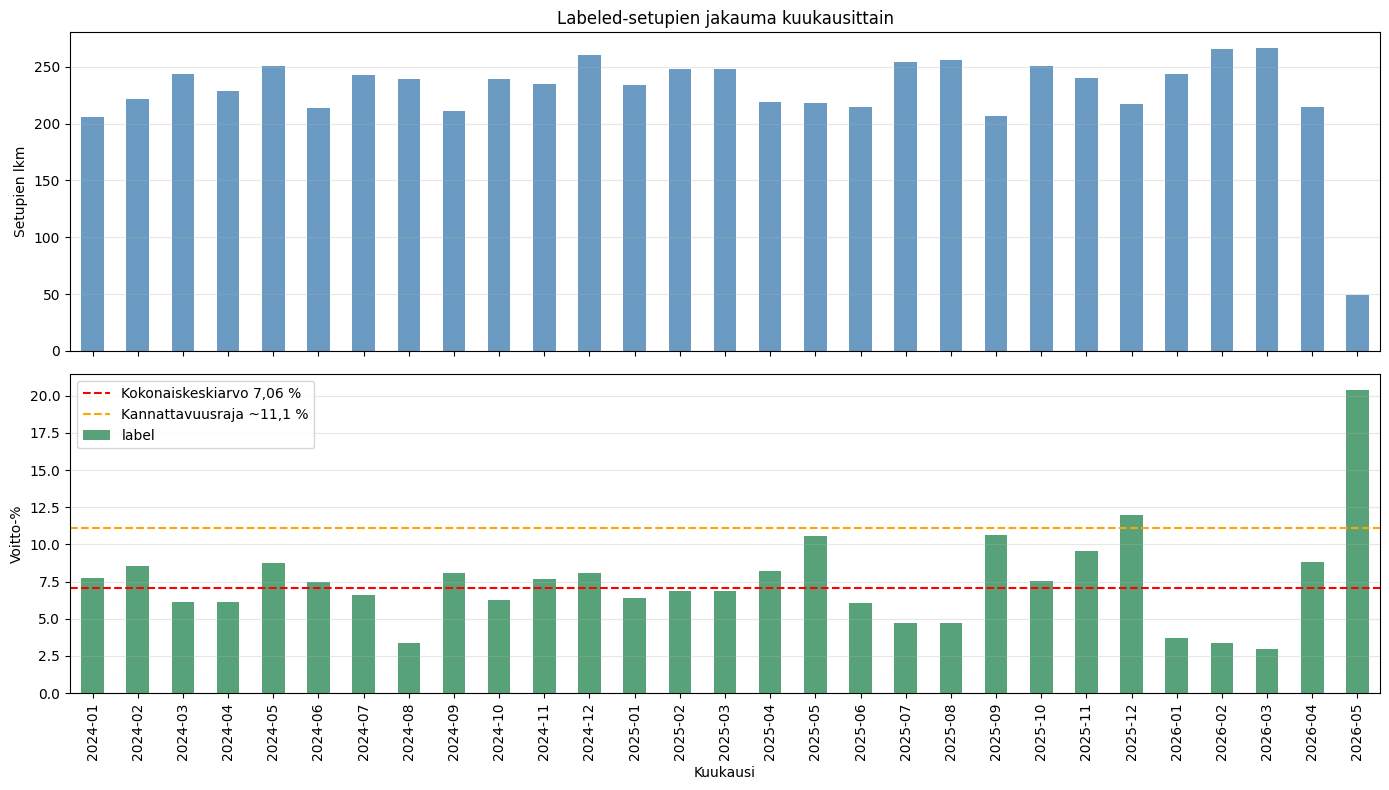

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Yläpaneeli: setupien lukumäärä per kuukausi
monthly_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_ylabel('Setupien lkm')
ax1.set_title('Labeled-setupien jakauma kuukausittain')
ax1.grid(axis='y', alpha=0.3)

# Alapaneeli: voitto-% per kuukausi
monthly_winrate.plot(kind='bar', ax=ax2, color='seagreen', alpha=0.8)
ax2.axhline(y=7.06, color='red', linestyle='--', label='Kokonaiskeskiarvo 7,06 %')
ax2.axhline(y=11.1, color='orange', linestyle='--', label='Kannattavuusraja ~11,1 %')
ax2.set_ylabel('Voitto-%')
ax2.set_xlabel('Kuukausi')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
SPLIT_DATE = pd.Timestamp('2025-10-01', tz='UTC')

train_mask = df_ml['entry_time'] < SPLIT_DATE
test_mask = df_ml['entry_time'] >= SPLIT_DATE

print(f"Train:  n = {train_mask.sum():,}, voitto-% = {df_ml.loc[train_mask, 'label'].mean()*100:.2f}%")
print(f"Test:   n = {test_mask.sum():,}, voitto-% = {df_ml.loc[test_mask, 'label'].mean()*100:.2f}%")
print(f"Suhde:  train {train_mask.sum() / len(df_ml)*100:.1f}% / test {test_mask.sum() / len(df_ml)*100:.1f}%")
print(f"\nTrain symboleittain:")
print(df_ml.loc[train_mask, 'symbol'].value_counts())
print(f"\nTest symboleittain:")
print(df_ml.loc[test_mask, 'symbol'].value_counts())
print(f"\nTrain suunnittain:")
print(df_ml.loc[train_mask, 'direction'].value_counts())
print(f"\nTest suunnittain:")
print(df_ml.loc[test_mask, 'direction'].value_counts())

Train:  n = 4,892, voitto-% = 7.07%
Test:   n = 1,749, voitto-% = 7.03%
Suhde:  train 73.7% / test 26.3%

Train symboleittain:
symbol
SOLUSDT    2565
ETHUSDT    2327
Name: count, dtype: int64

Test symboleittain:
symbol
SOLUSDT    892
ETHUSDT    857
Name: count, dtype: int64

Train suunnittain:
direction
short    2580
long     2312
Name: count, dtype: int64

Test suunnittain:
direction
long     984
short    765
Name: count, dtype: int64


In [6]:
# EV-funktio: laskee odotusarvon setup-joukolle
# Käyttää oletusta että jokaisessa setupissa riskataan yksi yksikkö (1R)
# - Voitto: +R/R-suhde (esim. 7.8R long-mediaanille)
# - Tappio: -1R
# Lisäksi otetaan huomioon kustannukset (spread + fee)

def calculate_ev(df, cost_per_trade=0.0015):
    """
    Laskee odotusarvon R-yksiköissä (1 R = riskattu määrä per setup).
    
    Parametrit:
    - df: DataFrame jossa pitää olla 'label' (0/1) ja 'risk_reward_ratio' sarakkeet
    - cost_per_trade: spread + fee yhteensä per kauppa, prosenttina hintaliikkeestä
                      0.0015 = 0,15 % (Binance taker fee 0,1 % + tyypillinen spread 0,05 %)
                      
    Palauttaa dict:n jossa: n, win_pct, avg_win_R, ev_per_trade_R, total_R
    """
    if len(df) == 0:
        return {'n': 0, 'win_pct': 0, 'avg_win_R': 0, 'ev_per_trade_R': 0, 'total_R': 0}
    
    n = len(df)
    win_pct = df['label'].mean()
    
    # Voittojen R/R-suhde keskimäärin (vain voitoista)
    winning_rr = df.loc[df['label'] == 1, 'risk_reward_ratio']
    avg_win_R = winning_rr.mean() if len(winning_rr) > 0 else 0
    
    # EV per kauppa = P(voitto) * R/R - P(tappio) * 1 - kustannus
    # Kustannus arvioidaan karkeasti: ~2x cost_per_trade (entry + exit), jaettuna
    # tyypillisellä boxin keskiliikkeellä (jos liike on 2 %, kustannus 0,3 % = 0,15 R)
    # Yksinkertaistettuna: vähennetään kiinteä kustannus per kauppa R-yksiköissä
    cost_R = cost_per_trade * 2 / 0.02  # Karkea arvio: ~0,15 R per kauppa
    
    ev_per_trade_R = win_pct * avg_win_R - (1 - win_pct) * 1.0 - cost_R
    total_R = ev_per_trade_R * n
    
    return {
        'n': n,
        'win_pct': win_pct * 100,
        'avg_win_R': avg_win_R,
        'ev_per_trade_R': ev_per_trade_R,
        'total_R': total_R
    }


# Sanity-tarkistus koko treenidatalle
ev_train_all = calculate_ev(df_ml.loc[train_mask])
print("Koko treenidata, ei filtteröintiä:")
for k, v in ev_train_all.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Koko treenidata, ei filtteröintiä:
  n: 4892
  win_pct: 7.073
  avg_win_R: 5.679
  ev_per_trade_R: -0.678
  total_R: -3314.729


In [7]:
# Baseline 1a: "Älä ota mitään setupia" (täydellinen pidättäytyminen)
# EV per kauppa = 0 (ei kauppoja), total_R = 0
print("BASELINE 1a: Älä ota mitään")
print(f"  EV per kauppa: 0.000 R")
print(f"  Total R: 0.000")
print(f"  n: 0\n")

# Baseline 1b: "Ota kaikki" (= koko treenidata)
ev_b1b_train = calculate_ev(df_ml.loc[train_mask])
ev_b1b_test = calculate_ev(df_ml.loc[test_mask])

print("BASELINE 1b: Ota kaikki")
print(f"  TRAIN: n={ev_b1b_train['n']:,}, win%={ev_b1b_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b1b_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b1b_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b1b_test['n']:,}, win%={ev_b1b_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b1b_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b1b_test['total_R']:+.1f} R")

BASELINE 1a: Älä ota mitään
  EV per kauppa: 0.000 R
  Total R: 0.000
  n: 0

BASELINE 1b: Ota kaikki
  TRAIN: n=4,892, win%=7.07%, EV/kauppa=-0.678 R, total=-3314.7 R
  TEST:  n=1,749, win%=7.03%, EV/kauppa=-0.660 R, total=-1153.5 R


In [8]:
# Baseline 2: Vain ensimmäinen setup per päivä
b2_train_mask = train_mask & (df_ml['setup_index_in_day'] == 1)
b2_test_mask = test_mask & (df_ml['setup_index_in_day'] == 1)

ev_b2_train = calculate_ev(df_ml.loc[b2_train_mask])
ev_b2_test = calculate_ev(df_ml.loc[b2_test_mask])

print("BASELINE 2: Vain ensimmäinen setup per päivä")
print(f"  TRAIN: n={ev_b2_train['n']:,}, win%={ev_b2_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b2_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b2_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b2_test['n']:,}, win%={ev_b2_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b2_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b2_test['total_R']:+.1f} R")

BASELINE 2: Vain ensimmäinen setup per päivä
  TRAIN: n=1,199, win%=11.34%, EV/kauppa=-0.431 R, total=-516.2 R
  TEST:  n=411, win%=9.98%, EV/kauppa=-0.557 R, total=-228.9 R


In [9]:
# Baseline 3: Yhdistetty sääntöfiltteri (Vaiheen 3 löytöjen pohjalta)

# Lasketaan kynnysarvot VAIN treenidatasta (ei look-ahead-vuotoa)
train_df = df_ml.loc[train_mask]
box_atr_median = train_df['box_size_vs_atr14d'].median()
atr_1h_median = train_df['atr_1h_pct'].median()

print(f"Treenidatan mediaanit:")
print(f"  box_size_vs_atr14d: {box_atr_median:.3f}")
print(f"  atr_1h_pct: {atr_1h_median:.5f}")

# Sääntöfunktio joka soveltuu mihin tahansa DataFrame-osajoukkoon
def baseline3_filter(df, box_thr, atr_thr):
    """Palauttaa boolean-maskin niistä setupeista jotka läpäisevät yhdistetyn filtterin."""
    base_rules = (
        (df['minutes_in_opposite_half'] < 175) &
        (df['box_size_vs_atr14d'] < box_thr) &
        (df['atr_1h_pct'] < atr_thr)
    )
    # Direction-spesifi RSI-ehto
    long_ok = (df['direction'] == 'long') & (df['rsi_1h'] > 44)
    short_ok = (df['direction'] == 'short') & (df['rsi_1h'] < 56)
    direction_rule = long_ok | short_ok
    
    return base_rules & direction_rule

# Sovelletaan treeniin ja testiin
b3_train = df_ml.loc[train_mask][baseline3_filter(df_ml.loc[train_mask], box_atr_median, atr_1h_median)]
b3_test = df_ml.loc[test_mask][baseline3_filter(df_ml.loc[test_mask], box_atr_median, atr_1h_median)]

ev_b3_train = calculate_ev(b3_train)
ev_b3_test = calculate_ev(b3_test)

print(f"\nBASELINE 3: Yhdistetty sääntöfiltteri")
print(f"  TRAIN: n={ev_b3_train['n']:,} ({ev_b3_train['n']/train_mask.sum()*100:.1f}% setupeista), "
      f"win%={ev_b3_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b3_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b3_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b3_test['n']:,} ({ev_b3_test['n']/test_mask.sum()*100:.1f}% setupeista), "
      f"win%={ev_b3_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b3_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b3_test['total_R']:+.1f} R")

Treenidatan mediaanit:
  box_size_vs_atr14d: 0.864
  atr_1h_pct: 0.01072

BASELINE 3: Yhdistetty sääntöfiltteri
  TRAIN: n=282 (5.8% setupeista), win%=24.47%, EV/kauppa=+0.117 R, total=+32.9 R
  TEST:  n=129 (7.4% setupeista), win%=17.05%, EV/kauppa=-0.330 R, total=-42.6 R


In [10]:
# Yhteenvetotaulukko kaikista baselineista
baseline_summary = pd.DataFrame([
    {'baseline': '1a: Älä ota mitään', 'set': 'train', 'n': 0, 'win_pct': 0, 'ev_per_trade_R': 0, 'total_R': 0},
    {'baseline': '1a: Älä ota mitään', 'set': 'test',  'n': 0, 'win_pct': 0, 'ev_per_trade_R': 0, 'total_R': 0},
    {'baseline': '1b: Ota kaikki', 'set': 'train', **{k: ev_b1b_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '1b: Ota kaikki', 'set': 'test',  **{k: ev_b1b_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '2: Ensimmäinen/päivä', 'set': 'train', **{k: ev_b2_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '2: Ensimmäinen/päivä', 'set': 'test',  **{k: ev_b2_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '3: Yhdistetty filtteri', 'set': 'train', **{k: ev_b3_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '3: Yhdistetty filtteri', 'set': 'test',  **{k: ev_b3_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
])

print(baseline_summary.to_string(index=False))

              baseline   set    n   win_pct  ev_per_trade_R      total_R
    1a: Älä ota mitään train    0  0.000000        0.000000     0.000000
    1a: Älä ota mitään  test    0  0.000000        0.000000     0.000000
        1b: Ota kaikki train 4892  7.072772       -0.677582 -3314.728895
        1b: Ota kaikki  test 1749  7.032590       -0.659522 -1153.503919
  2: Ensimmäinen/päivä train 1199 11.342786       -0.430524  -516.198685
  2: Ensimmäinen/päivä  test  411  9.975669       -0.557039  -228.942846
3: Yhdistetty filtteri train  282 24.468085        0.116721    32.915211
3: Yhdistetty filtteri  test  129 17.054264       -0.330257   -42.603116


In [11]:
# Tallennetaan baseline-tulokset
import os
os.makedirs('../models', exist_ok=True)
baseline_summary.to_parquet('../models/baseline_results.parquet')
print("Tallennettu: ../models/baseline_results.parquet")
print(f"\nLopulliset baseline-tulokset:")
print(baseline_summary.to_string(index=False))

Tallennettu: ../models/baseline_results.parquet

Lopulliset baseline-tulokset:
              baseline   set    n   win_pct  ev_per_trade_R      total_R
    1a: Älä ota mitään train    0  0.000000        0.000000     0.000000
    1a: Älä ota mitään  test    0  0.000000        0.000000     0.000000
        1b: Ota kaikki train 4892  7.072772       -0.677582 -3314.728895
        1b: Ota kaikki  test 1749  7.032590       -0.659522 -1153.503919
  2: Ensimmäinen/päivä train 1199 11.342786       -0.430524  -516.198685
  2: Ensimmäinen/päivä  test  411  9.975669       -0.557039  -228.942846
3: Yhdistetty filtteri train  282 24.468085        0.116721    32.915211
3: Yhdistetty filtteri  test  129 17.054264       -0.330257   -42.603116


In [14]:
# ============================================================
# Random Forest (a priori -regularisoitu) — KORJATTU PIIRRELISTA
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

# --- 1. Piirreavaruus (17 mallinnukseen menevää saraketta) ---
FEATURES = [
    # Ryhmä A
    'setup_index_in_day', 'direction', 'risk_reward_ratio',
    'entry_position_in_box', 'entry_outside_box',
    'hour_sin', 'hour_cos',
    # Ryhmä B
    'prev_day_range_pct', 'box_size_vs_atr14d',
    # Ryhmä C (ema50_4h ja ema200_4h pois apupiirteinä)
    'trend_4h', 'trend_aligned',
    # Ryhmä D
    'atr_15m_vs_atr_daily', 'atr_1h_pct', 'rsi_1h', 'volume_vs_ma20_15m',
    # Ryhmä E
    'reversal_candle_size_pct', 'minutes_in_opposite_half',
]

# direction str → int
if df_ml['direction'].dtype == object:
    df_ml['direction'] = (df_ml['direction'] == 'long').astype(int)

# Tarkista että kaikki piirteet löytyvät
missing = [f for f in FEATURES if f not in df_ml.columns]
assert not missing, f"Puuttuvia piirteitä: {missing}"
print(f"✓ Kaikki {len(FEATURES)} piirrettä löytyvät datasta")

# NaN-tarkistus
nan_counts = df_ml[FEATURES].isna().sum()
print("\nNaN-arvot per piirre:")
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "  Ei NaN-arvoja ✓")

# Pudota NaN-rivit (Ryhmä C:n EMAt voivat puuttua alkupäivissä)
n_before = len(df_ml)
df_ml = df_ml.dropna(subset=FEATURES).copy()
n_dropped = n_before - len(df_ml)
print(f"Pudotettu {n_dropped} riviä NaN:ien takia ({n_dropped/n_before*100:.2f} %)")

# Päivitä maskit NaN-pudotusten jälkeen
train_mask = df_ml['entry_time'] < SPLIT_DATE
test_mask = df_ml['entry_time'] >= SPLIT_DATE

X_train = df_ml.loc[train_mask, FEATURES].values
y_train = df_ml.loc[train_mask, 'label'].values
X_test = df_ml.loc[test_mask, FEATURES].values
y_test = df_ml.loc[test_mask, 'label'].values

df_train = df_ml.loc[train_mask].copy()
df_test = df_ml.loc[test_mask].copy()

print(f"\nTrain: {len(X_train)} setupia, voitto-% {y_train.mean()*100:.2f}")
print(f"Test:  {len(X_test)} setupia, voitto-% {y_test.mean()*100:.2f}")

✓ Kaikki 17 piirrettä löytyvät datasta

NaN-arvot per piirre:
box_size_vs_atr14d    75
dtype: int64
Pudotettu 75 riviä NaN:ien takia (1.13 %)

Train: 4817 setupia, voitto-% 7.06
Test:  1749 setupia, voitto-% 7.03


In [21]:
# --- 2. RF-malli (a priori -parametrit) ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=30,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

def evaluate_threshold(df_subset, y_pred_proba, threshold, cost_per_trade=0.0015):
    """Laske EV/kauppa kun otetaan kaupat joissa p > threshold."""
    take_mask = y_pred_proba > threshold
    n = int(take_mask.sum())
    if n == 0:
        return 0.0, 0
    taken = df_subset[take_mask]
    result = calculate_ev(taken, cost_per_trade=cost_per_trade)
    return float(result['ev_per_trade_R']), n

print("✓ RF-malli ja evaluate_threshold valmiina")

✓ RF-malli ja evaluate_threshold valmiina


In [17]:
print(f"direction dtype: {df_ml['direction'].dtype}")
print(f"Unikkiset arvot: {df_ml['direction'].unique()}")
print(f"X_train[0, :] dtypes: train arrayn ensimmäinen rivi näyttää tältä:")
print(df_ml[FEATURES].dtypes)

direction dtype: str
Unikkiset arvot: <ArrowStringArray>
['short', 'long']
Length: 2, dtype: str
X_train[0, :] dtypes: train arrayn ensimmäinen rivi näyttää tältä:
setup_index_in_day            int64
direction                       str
risk_reward_ratio           float64
entry_position_in_box       float64
entry_outside_box             int64
hour_sin                    float64
hour_cos                    float64
prev_day_range_pct          float64
box_size_vs_atr14d          float64
trend_4h                    float64
trend_aligned                 int64
atr_15m_vs_atr_daily        float64
atr_1h_pct                  float64
rsi_1h                      float64
volume_vs_ma20_15m          float64
reversal_candle_size_pct    float64
minutes_in_opposite_half      int64
dtype: object


In [18]:
# Pakota direction → int (ei ehtoja)
df_ml['direction'] = (df_ml['direction'].astype(str) == 'long').astype(int)

# Rakennetaan X_train ja X_test uudelleen muunnoksen jälkeen
X_train = df_ml.loc[train_mask, FEATURES].values
y_train = df_ml.loc[train_mask, 'label'].values
X_test = df_ml.loc[test_mask, FEATURES].values
y_test = df_ml.loc[test_mask, 'label'].values

df_train = df_ml.loc[train_mask].copy()
df_test = df_ml.loc[test_mask].copy()

# Varmistus
print(f"direction unikkiset arvot: {df_ml['direction'].unique()}")
print(f"X_train dtype: {X_train.dtype}")  # pitäisi olla float64 tai int64
print(f"X_train shape: {X_train.shape}")

direction unikkiset arvot: [0 1]
X_train dtype: float64
X_train shape: (4817, 17)


In [22]:
# --- 3. Threshold tuning EV:llä TimeSeriesSplit-CV:ssä ---
tscv = TimeSeriesSplit(n_splits=5)  # expanding window (default)
thresholds_to_test = np.arange(0.30, 0.80, 0.02)

cv_results = []

print("--- TimeSeriesSplit CV (expanding window) ---")
for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    rf_fold = RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=30,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1,
    )
    rf_fold.fit(X_train[tr_idx], y_train[tr_idx])
    val_proba = rf_fold.predict_proba(X_train[val_idx])[:, 1]
    df_val = df_train.iloc[val_idx]

    for thr in thresholds_to_test:
        ev, n = evaluate_threshold(df_val, val_proba, thr)
        cv_results.append({'fold': fold_idx, 'threshold': thr, 'ev': ev, 'n_trades': n})

    best_thr_fold = max(thresholds_to_test,
                       key=lambda t: evaluate_threshold(df_val, val_proba, t)[0])
    best_ev_fold, best_n_fold = evaluate_threshold(df_val, val_proba, best_thr_fold)
    print(f"  Fold {fold_idx}: paras thr={best_thr_fold:.2f}, "
          f"EV={best_ev_fold:+.3f} R, n={best_n_fold} "
          f"(treeni n={len(tr_idx)}, val n={len(val_idx)})")

cv_df = pd.DataFrame(cv_results)

--- TimeSeriesSplit CV (expanding window) ---
  Fold 0: paras thr=0.74, EV=+0.877 R, n=4 (treeni n=807, val n=802)
  Fold 1: paras thr=0.76, EV=+1.328 R, n=2 (treeni n=1609, val n=802)
  Fold 2: paras thr=0.76, EV=+0.829 R, n=4 (treeni n=2411, val n=802)
  Fold 3: paras thr=0.66, EV=+0.316 R, n=101 (treeni n=3213, val n=802)
  Fold 4: paras thr=0.76, EV=+0.514 R, n=9 (treeni n=4015, val n=802)


In [20]:
test_result = calculate_ev(df_train.head(50))
print(f"calculate_ev palauttaa: {type(test_result)}")
print(f"Arvo: {test_result}")

calculate_ev palauttaa: <class 'dict'>
Arvo: {'n': 50, 'win_pct': np.float64(8.0), 'avg_win_R': np.float64(3.736664747396498), 'ev_per_trade_R': np.float64(-0.7710668202082802), 'total_R': np.float64(-38.55334101041401)}


Threshold-spektri (kaikki):
 threshold   mean_ev  median_ev    min_ev    max_ev  mean_n  min_n
      0.30 -0.387217  -0.337488 -0.596189 -0.254768   388.2    359
      0.32 -0.367003  -0.296862 -0.565045 -0.266876   367.6    342
      0.34 -0.353796  -0.318620 -0.557414 -0.234202   345.0    322
      0.36 -0.333472  -0.334515 -0.526735 -0.188005   327.0    307
      0.38 -0.300513  -0.277687 -0.496462 -0.133723   308.2    287
      0.40 -0.267362  -0.270996 -0.488216 -0.076515   290.2    272
      0.42 -0.236351  -0.233913 -0.458992 -0.020850   273.6    255
      0.44 -0.211914  -0.211649 -0.434775 -0.050110   258.2    238
      0.46 -0.190696  -0.142930 -0.404232 -0.070531   241.4    219
      0.48 -0.189260  -0.178491 -0.391473 -0.074500   226.0    206
      0.50 -0.164121  -0.185293 -0.329277 -0.046896   212.8    193
      0.52 -0.156760  -0.129448 -0.378812 -0.017096   199.6    173
      0.54 -0.111856  -0.147669 -0.324811  0.064604   183.4    157
      0.56 -0.131311  -0.158427 -0

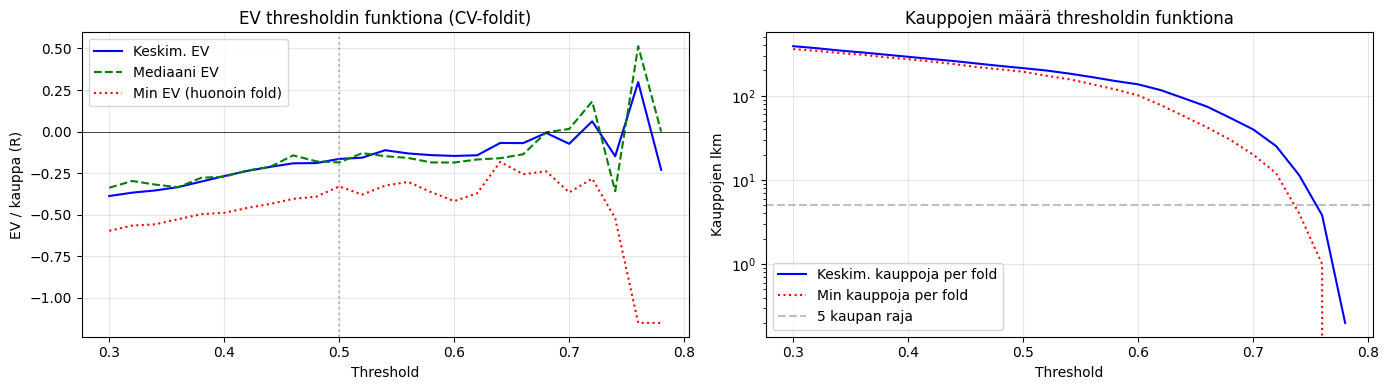

In [23]:
# Solu 3.5: Threshold-spektri foldien yli
import matplotlib.pyplot as plt

agg_full = cv_df.groupby('threshold').agg(
    mean_ev=('ev', 'mean'),
    median_ev=('ev', 'median'),
    min_ev=('ev', 'min'),
    max_ev=('ev', 'max'),
    mean_n=('n_trades', 'mean'),
    min_n=('n_trades', 'min'),
).reset_index()

print("Threshold-spektri (kaikki):")
print(agg_full.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(agg_full['threshold'], agg_full['mean_ev'], 'b-', label='Keskim. EV')
axes[0].plot(agg_full['threshold'], agg_full['median_ev'], 'g--', label='Mediaani EV')
axes[0].plot(agg_full['threshold'], agg_full['min_ev'], 'r:', label='Min EV (huonoin fold)')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(x=0.5, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('EV / kauppa (R)')
axes[0].set_title('EV thresholdin funktiona (CV-foldit)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(agg_full['threshold'], agg_full['mean_n'], 'b-', label='Keskim. kauppoja per fold')
axes[1].plot(agg_full['threshold'], agg_full['min_n'], 'r:', label='Min kauppoja per fold')
axes[1].axhline(5, color='gray', ls='--', alpha=0.5, label='5 kaupan raja')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Kauppojen lkm')
axes[1].set_title('Kauppojen määrä thresholdin funktiona')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Solu 4 — TIUKENNETTU: vaadi myös min_n >= 5 (ei pelkkä keskiarvo)
agg = cv_df.groupby('threshold').agg(
    mean_ev=('ev', 'mean'),
    median_ev=('ev', 'median'),
    min_ev=('ev', 'min'),
    mean_n=('n_trades', 'mean'),
    min_n=('n_trades', 'min'),
).reset_index()

# Tiukennus: jokaisessa foldissa vähintään 5 kauppaa
agg_valid = agg[(agg['mean_n'] >= 5) & (agg['min_n'] >= 5)].copy()

if len(agg_valid) == 0:
    print("⚠ Mikään threshold ei täytä min_n >= 5 -ehtoa")
    print("→ Löystetään: vaaditaan min_n >= 2")
    agg_valid = agg[(agg['mean_n'] >= 5) & (agg['min_n'] >= 2)].copy()

best_row = agg_valid.loc[agg_valid['mean_ev'].idxmax()]
best_threshold = best_row['threshold']

print(f"--- Threshold-valinta (tiukennettu: min_n >= 5) ---")
print(f"Paras threshold: {best_threshold:.2f}")
print(f"  Keskim. EV foldeissa: {best_row['mean_ev']:+.3f} R")
print(f"  Mediaani EV:        {best_row['median_ev']:+.3f} R")
print(f"  Min EV (worst fold): {best_row['min_ev']:+.3f} R")
print(f"  Keskim. kauppoja per fold: {best_row['mean_n']:.0f}")
print(f"  Min kauppoja per fold:   {best_row['min_n']:.0f}")

--- Threshold-valinta (tiukennettu: min_n >= 5) ---
Paras threshold: 0.72
  Keskim. EV foldeissa: +0.062 R
  Mediaani EV:        +0.181 R
  Min EV (worst fold): -0.283 R
  Keskim. kauppoja per fold: 25
  Min kauppoja per fold:   12


In [25]:
# --- 4. Lopullinen malli koko treenidatalla ja arviointi testissä ---
rf.fit(X_train, y_train)

train_proba = rf.predict_proba(X_train)[:, 1]
test_proba = rf.predict_proba(X_test)[:, 1]

train_ev, train_n = evaluate_threshold(df_train, train_proba, best_threshold)
test_ev, test_n = evaluate_threshold(df_test, test_proba, best_threshold)

print(f"--- Lopullinen Random Forest (threshold={best_threshold:.2f}) ---")
print(f"Train: EV={train_ev:+.3f} R/kauppa, n={train_n} ({train_n/len(df_train)*100:.1f} % setupeista)")
print(f"Test:  EV={test_ev:+.3f} R/kauppa, n={test_n} ({test_n/len(df_test)*100:.1f} % setupeista)")
print(f"Train→Test ero: {test_ev-train_ev:+.3f} R")

print(f"\n--- Vertailu baselineihin (testissä) ---")
print(f"  Baseline 1a (älä mitään):    EV =  0,000 R  ← rima")
print(f"  Baseline 1b (ota kaikki):    EV = -0,660 R")
print(f"  Baseline 3 (sääntöfiltteri): EV = -0,330 R")
print(f"  Random Forest:               EV = {test_ev:+.3f} R")

print(f"\n--- Train→test -ero overfit-mittarina ---")
print(f"  Baseline 3:    -0,447 R (Löytö #23)")
print(f"  Random Forest: {test_ev-train_ev:+.3f} R")

--- Lopullinen Random Forest (threshold=0.72) ---
Train: EV=+0.245 R/kauppa, n=323 (6.7 % setupeista)
Test:  EV=-0.283 R/kauppa, n=127 (7.3 % setupeista)
Train→Test ero: -0.528 R

--- Vertailu baselineihin (testissä) ---
  Baseline 1a (älä mitään):    EV =  0,000 R  ← rima
  Baseline 1b (ota kaikki):    EV = -0,660 R
  Baseline 3 (sääntöfiltteri): EV = -0,330 R
  Random Forest:               EV = -0.283 R

--- Train→test -ero overfit-mittarina ---
  Baseline 3:    -0,447 R (Löytö #23)
  Random Forest: -0.528 R


In [26]:
# --- 5. Feature importance ---
fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

print("--- Feature importance (kaikki) ---")
print(fi.to_string(index=False))

# --- 6. Tallennus ---
import joblib
joblib.dump(rf, '../models/random_forest_v1.pkl')

results_rf = {
    'model': 'random_forest_v1',
    'threshold': float(best_threshold),
    'train_ev': float(train_ev), 'train_n': int(train_n),
    'test_ev': float(test_ev), 'test_n': int(test_n),
    'train_test_diff': float(test_ev - train_ev),
    'cv_mean_ev': float(best_row['mean_ev']),
    'cv_min_ev': float(best_row['min_ev']),
    'hyperparams': {
        'n_estimators': 300, 'max_depth': 5,
        'min_samples_leaf': 30, 'max_features': 'sqrt',
        'class_weight': 'balanced', 'random_state': 42,
    }
}
print(f"\n✓ Tallennettu models/random_forest_v1.pkl")

--- Feature importance (kaikki) ---
                 feature  importance
       risk_reward_ratio    0.293816
minutes_in_opposite_half    0.149055
      box_size_vs_atr14d    0.101348
       entry_outside_box    0.065833
                  rsi_1h    0.051718
      prev_day_range_pct    0.050762
      setup_index_in_day    0.045709
   entry_position_in_box    0.042415
                hour_sin    0.039157
                hour_cos    0.038806
              atr_1h_pct    0.032989
    atr_15m_vs_atr_daily    0.027791
reversal_candle_size_pct    0.025637
                trend_4h    0.016544
      volume_vs_ma20_15m    0.016203
           trend_aligned    0.001572
               direction    0.000645

✓ Tallennettu models/random_forest_v1.pkl


In [27]:
# ============================================================
# XGBoost (a priori -regularisoitu)
# ============================================================
import xgboost as xgb

# class imbalance kerroin
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {n_neg}/{n_pos} = {scale_pos_weight:.2f}")

xgb_params = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model = xgb.XGBClassifier(**xgb_params)
print("✓ XGBoost-malli valmiina")

scale_pos_weight = 4477/340 = 13.17
✓ XGBoost-malli valmiina


In [28]:
cv_results_xgb = []

print("--- XGBoost TimeSeriesSplit CV (expanding window) ---")
for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    xgb_fold = xgb.XGBClassifier(**xgb_params)
    xgb_fold.fit(X_train[tr_idx], y_train[tr_idx])
    val_proba = xgb_fold.predict_proba(X_train[val_idx])[:, 1]
    df_val = df_train.iloc[val_idx]

    for thr in thresholds_to_test:
        ev, n = evaluate_threshold(df_val, val_proba, thr)
        cv_results_xgb.append({'fold': fold_idx, 'threshold': thr, 'ev': ev, 'n_trades': n})

    best_thr_fold = max(thresholds_to_test,
                       key=lambda t: evaluate_threshold(df_val, val_proba, t)[0])
    best_ev_fold, best_n_fold = evaluate_threshold(df_val, val_proba, best_thr_fold)
    print(f"  Fold {fold_idx}: paras thr={best_thr_fold:.2f}, "
          f"EV={best_ev_fold:+.3f} R, n={best_n_fold}")

cv_df_xgb = pd.DataFrame(cv_results_xgb)

--- XGBoost TimeSeriesSplit CV (expanding window) ---
  Fold 0: paras thr=0.74, EV=-0.060 R, n=67
  Fold 1: paras thr=0.78, EV=+0.075 R, n=33
  Fold 2: paras thr=0.74, EV=+0.597 R, n=37
  Fold 3: paras thr=0.74, EV=+0.740 R, n=40
  Fold 4: paras thr=0.78, EV=+0.030 R, n=47


In [29]:
agg_xgb = cv_df_xgb.groupby('threshold').agg(
    mean_ev=('ev', 'mean'),
    median_ev=('ev', 'median'),
    min_ev=('ev', 'min'),
    mean_n=('n_trades', 'mean'),
    min_n=('n_trades', 'min'),
).reset_index()

agg_valid_xgb = agg_xgb[(agg_xgb['mean_n'] >= 5) & (agg_xgb['min_n'] >= 5)].copy()

if len(agg_valid_xgb) == 0:
    print("⚠ Mikään threshold ei täytä min_n >= 5 -ehtoa, löystetään min_n >= 2")
    agg_valid_xgb = agg_xgb[(agg_xgb['mean_n'] >= 5) & (agg_xgb['min_n'] >= 2)].copy()

best_row_xgb = agg_valid_xgb.loc[agg_valid_xgb['mean_ev'].idxmax()]
best_threshold_xgb = best_row_xgb['threshold']

print(f"--- XGBoost threshold-valinta ---")
print(f"Paras threshold: {best_threshold_xgb:.2f}")
print(f"  Keskim. EV foldeissa: {best_row_xgb['mean_ev']:+.3f} R")
print(f"  Mediaani EV:        {best_row_xgb['median_ev']:+.3f} R")
print(f"  Min EV (worst fold): {best_row_xgb['min_ev']:+.3f} R")
print(f"  Keskim. kauppoja per fold: {best_row_xgb['mean_n']:.0f}")
print(f"  Min kauppoja per fold:   {best_row_xgb['min_n']:.0f}")

--- XGBoost threshold-valinta ---
Paras threshold: 0.74
  Keskim. EV foldeissa: +0.203 R
  Mediaani EV:        -0.006 R
  Min EV (worst fold): -0.254 R
  Keskim. kauppoja per fold: 52
  Min kauppoja per fold:   37


In [30]:
xgb_model.fit(X_train, y_train)

train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

train_ev_xgb, train_n_xgb = evaluate_threshold(df_train, train_proba_xgb, best_threshold_xgb)
test_ev_xgb, test_n_xgb = evaluate_threshold(df_test, test_proba_xgb, best_threshold_xgb)

print(f"--- Lopullinen XGBoost (threshold={best_threshold_xgb:.2f}) ---")
print(f"Train: EV={train_ev_xgb:+.3f} R/kauppa, n={train_n_xgb} ({train_n_xgb/len(df_train)*100:.1f} %)")
print(f"Test:  EV={test_ev_xgb:+.3f} R/kauppa, n={test_n_xgb} ({test_n_xgb/len(df_test)*100:.1f} %)")
print(f"Train→Test ero: {test_ev_xgb-train_ev_xgb:+.3f} R")

print(f"\n--- Vertailu (testissä) ---")
print(f"  Baseline 1a:    EV =  0,000 R  ← rima")
print(f"  Random Forest:  EV = -0,283 R")
print(f"  XGBoost:        EV = {test_ev_xgb:+.3f} R")

# Feature importance
fi_xgb = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)
print("\n--- XGBoost feature importance ---")
print(fi_xgb.to_string(index=False))

# Tallennus
import joblib
joblib.dump(xgb_model, '../models/xgboost_v1.pkl')

results_xgb = {
    'model': 'xgboost_v1',
    'threshold': float(best_threshold_xgb),
    'train_ev': float(train_ev_xgb), 'train_n': int(train_n_xgb),
    'test_ev': float(test_ev_xgb), 'test_n': int(test_n_xgb),
    'train_test_diff': float(test_ev_xgb - train_ev_xgb),
    'cv_mean_ev': float(best_row_xgb['mean_ev']),
    'cv_min_ev': float(best_row_xgb['min_ev']),
    'hyperparams': xgb_params,
}
print(f"\n✓ Tallennettu models/xgboost_v1.pkl")

--- Lopullinen XGBoost (threshold=0.74) ---
Train: EV=+1.871 R/kauppa, n=456 (9.5 %)
Test:  EV=-0.176 R/kauppa, n=176 (10.1 %)
Train→Test ero: -2.046 R

--- Vertailu (testissä) ---
  Baseline 1a:    EV =  0,000 R  ← rima
  Random Forest:  EV = -0,283 R
  XGBoost:        EV = -0.176 R

--- XGBoost feature importance ---
                 feature  importance
       entry_outside_box    0.218872
       risk_reward_ratio    0.123562
minutes_in_opposite_half    0.069665
      box_size_vs_atr14d    0.061883
      setup_index_in_day    0.053038
      prev_day_range_pct    0.052321
                hour_sin    0.051920
                  rsi_1h    0.046543
              atr_1h_pct    0.044187
reversal_candle_size_pct    0.043936
                hour_cos    0.037153
   entry_position_in_box    0.037141
                trend_4h    0.033581
    atr_15m_vs_atr_daily    0.033549
           trend_aligned    0.032809
      volume_vs_ma20_15m    0.031995
               direction    0.027844

✓ Tallennett

In [34]:
# ============================================================
# LightGBM (a priori -regularisoitu)
# ============================================================
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

lgb_params = dict(
    n_estimators=300,
    max_depth=4,
    num_leaves=15,           # 2^4 - 1, estää leaf-wise overfittiä
    learning_rate=0.05,
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=1,        # tarvitaan että subsample aktivoituu
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=-1,              # vaimentaa LightGBM:n verbose-tulosteet
)
lgb_model = lgb.LGBMClassifier(**lgb_params)
print("✓ LightGBM-malli valmiina")

✓ LightGBM-malli valmiina


In [33]:
cv_results_lgb = []

print("--- LightGBM TimeSeriesSplit CV (expanding window) ---")
for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    lgb_fold = lgb.LGBMClassifier(**lgb_params)
    lgb_fold.fit(X_train[tr_idx], y_train[tr_idx])
    val_proba = lgb_fold.predict_proba(X_train[val_idx])[:, 1]
    df_val = df_train.iloc[val_idx]

    for thr in thresholds_to_test:
        ev, n = evaluate_threshold(df_val, val_proba, thr)
        cv_results_lgb.append({'fold': fold_idx, 'threshold': thr, 'ev': ev, 'n_trades': n})

    best_thr_fold = max(thresholds_to_test,
                       key=lambda t: evaluate_threshold(df_val, val_proba, t)[0])
    best_ev_fold, best_n_fold = evaluate_threshold(df_val, val_proba, best_thr_fold)
    print(f"  Fold {fold_idx}: paras thr={best_thr_fold:.2f}, "
          f"EV={best_ev_fold:+.3f} R, n={best_n_fold}")

cv_df_lgb = pd.DataFrame(cv_results_lgb)

--- LightGBM TimeSeriesSplit CV (expanding window) ---
  Fold 0: paras thr=0.36, EV=+0.045 R, n=94


/Users/sbanbe/Documents/projektit/boxmethod/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sbanbe/Documents/projektit/boxmethod/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: paras thr=0.76, EV=+0.421 R, n=20


/Users/sbanbe/Documents/projektit/boxmethod/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: paras thr=0.78, EV=+0.358 R, n=24


/Users/sbanbe/Documents/projektit/boxmethod/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 3: paras thr=0.54, EV=+0.350 R, n=93
  Fold 4: paras thr=0.78, EV=+0.322 R, n=35


/Users/sbanbe/Documents/projektit/boxmethod/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
agg_lgb = cv_df_lgb.groupby('threshold').agg(
    mean_ev=('ev', 'mean'),
    median_ev=('ev', 'median'),
    min_ev=('ev', 'min'),
    mean_n=('n_trades', 'mean'),
    min_n=('n_trades', 'min'),
).reset_index()

agg_valid_lgb = agg_lgb[(agg_lgb['mean_n'] >= 5) & (agg_lgb['min_n'] >= 5)].copy()

if len(agg_valid_lgb) == 0:
    print("⚠ Mikään threshold ei täytä min_n >= 5, löystetään min_n >= 2")
    agg_valid_lgb = agg_lgb[(agg_lgb['mean_n'] >= 5) & (agg_lgb['min_n'] >= 2)].copy()

best_row_lgb = agg_valid_lgb.loc[agg_valid_lgb['mean_ev'].idxmax()]
best_threshold_lgb = best_row_lgb['threshold']

print(f"--- LightGBM threshold-valinta ---")
print(f"Paras threshold: {best_threshold_lgb:.2f}")
print(f"  Keskim. EV foldeissa: {best_row_lgb['mean_ev']:+.3f} R")
print(f"  Mediaani EV:        {best_row_lgb['median_ev']:+.3f} R")
print(f"  Min EV (worst fold): {best_row_lgb['min_ev']:+.3f} R")
print(f"  Keskim. kauppoja per fold: {best_row_lgb['mean_n']:.0f}")
print(f"  Min kauppoja per fold:   {best_row_lgb['min_n']:.0f}")

--- LightGBM threshold-valinta ---
Paras threshold: 0.78
  Keskim. EV foldeissa: +0.225 R
  Mediaani EV:        +0.322 R
  Min EV (worst fold): -0.077 R
  Keskim. kauppoja per fold: 23
  Min kauppoja per fold:   14


In [36]:
lgb_model.fit(X_train, y_train)

train_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
test_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

train_ev_lgb, train_n_lgb = evaluate_threshold(df_train, train_proba_lgb, best_threshold_lgb)
test_ev_lgb, test_n_lgb = evaluate_threshold(df_test, test_proba_lgb, best_threshold_lgb)

print(f"--- Lopullinen LightGBM (threshold={best_threshold_lgb:.2f}) ---")
print(f"Train: EV={train_ev_lgb:+.3f} R/kauppa, n={train_n_lgb} ({train_n_lgb/len(df_train)*100:.1f} %)")
print(f"Test:  EV={test_ev_lgb:+.3f} R/kauppa, n={test_n_lgb} ({test_n_lgb/len(df_test)*100:.1f} %)")
print(f"Train→Test ero: {test_ev_lgb-train_ev_lgb:+.3f} R")

print(f"\n--- Vertailu (testissä) ---")
print(f"  Baseline 1a:    EV =  0,000 R  ← rima")
print(f"  Random Forest:  EV = -0,283 R")
print(f"  XGBoost:        EV = -0,176 R")
print(f"  LightGBM:       EV = {test_ev_lgb:+.3f} R")

# Feature importance
fi_lgb = pd.DataFrame({
    'feature': FEATURES,
    'importance': lgb_model.feature_importances_,
}).sort_values('importance', ascending=False)
print("\n--- LightGBM feature importance ---")
print(fi_lgb.to_string(index=False))

# Tallennus
import joblib
joblib.dump(lgb_model, '../models/lightgbm_v1.pkl')

results_lgb = {
    'model': 'lightgbm_v1',
    'threshold': float(best_threshold_lgb),
    'train_ev': float(train_ev_lgb), 'train_n': int(train_n_lgb),
    'test_ev': float(test_ev_lgb), 'test_n': int(test_n_lgb),
    'train_test_diff': float(test_ev_lgb - train_ev_lgb),
    'cv_mean_ev': float(best_row_lgb['mean_ev']),
    'cv_min_ev': float(best_row_lgb['min_ev']),
    'hyperparams': {k: v for k, v in lgb_params.items() if k != 'verbose'},
}
print(f"\n✓ Tallennettu models/lightgbm_v1.pkl")

--- Lopullinen LightGBM (threshold=0.78) ---
Train: EV=+3.551 R/kauppa, n=325 (6.7 %)
Test:  EV=-0.342 R/kauppa, n=87 (5.0 %)
Train→Test ero: -3.892 R

--- Vertailu (testissä) ---
  Baseline 1a:    EV =  0,000 R  ← rima
  Random Forest:  EV = -0,283 R
  XGBoost:        EV = -0,176 R
  LightGBM:       EV = -0.342 R

--- LightGBM feature importance ---
                 feature  importance
      prev_day_range_pct         391
       risk_reward_ratio         324
              atr_1h_pct         302
      box_size_vs_atr14d         293
reversal_candle_size_pct         267
                trend_4h         266
minutes_in_opposite_half         257
      volume_vs_ma20_15m         254
   entry_position_in_box         253
                  rsi_1h         240
    atr_15m_vs_atr_daily         218
                hour_sin         113
                hour_cos          69
      setup_index_in_day          68
       entry_outside_box          26
           trend_aligned          13
               dir

In [40]:
# ============================================================
# Stacking ensemble: RF + XGBoost + LightGBM → Logistic Regression
# ============================================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base learners — täsmälleen samat kuin yksittäismalleissa
base_estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=30,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1,
    )),
    ('xgb', xgb.XGBClassifier(**xgb_params)),
    ('lgb', lgb.LGBMClassifier(**lgb_params)),
]

# Meta-learner: yksinkertainen logistic regression
# - C=1.0 (lievä regularisointi, sklearn-default)
# - class_weight='balanced' yhdenmukaisuus base-mallien kanssa
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)

# Stacking-malli
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=KFold(n_splits=3, shuffle=False),   # <-- VAIHDETTU tscv → KFold
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)

print("✓ Stacking-malli määritelty")
print(f"  Base learners: {[name for name, _ in base_estimators]}")
print(f"  Meta-learner: LogisticRegression(C=1.0, class_weight='balanced')")
print(f"  Out-of-fold strategia: TimeSeriesSplit ({tscv.n_splits} foldia)")

✓ Stacking-malli määritelty
  Base learners: ['rf', 'xgb', 'lgb']
  Meta-learner: LogisticRegression(C=1.0, class_weight='balanced')
  Out-of-fold strategia: TimeSeriesSplit (5 foldia)


In [41]:
from sklearn.model_selection import KFold

cv_results_stack = []

print("--- Stacking TimeSeriesSplit CV (expanding window, NESTED) ---")
print("    Huom: ulompi CV = TimeSeriesSplit (oikea aikadisipliini)")
print("    Sisempi CV = KFold(shuffle=False) — vaaditaan partitioksi sklearnilta.")
print("    Tämä kestää 5–10 min.\n")

inner_cv = KFold(n_splits=3, shuffle=False)

for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    base_fold = [
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=5, min_samples_leaf=30,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1,
        )),
        ('xgb', xgb.XGBClassifier(**xgb_params)),
        ('lgb', lgb.LGBMClassifier(**lgb_params)),
    ]
    stack_fold = StackingClassifier(
        estimators=base_fold,
        final_estimator=LogisticRegression(
            C=1.0, class_weight='balanced', max_iter=1000, random_state=42,
        ),
        cv=inner_cv,
        stack_method='predict_proba',
        n_jobs=-1,
    )
    stack_fold.fit(X_train[tr_idx], y_train[tr_idx])
    val_proba = stack_fold.predict_proba(X_train[val_idx])[:, 1]
    df_val = df_train.iloc[val_idx]

    for thr in thresholds_to_test:
        ev, n = evaluate_threshold(df_val, val_proba, thr)
        cv_results_stack.append({'fold': fold_idx, 'threshold': thr, 'ev': ev, 'n_trades': n})

    best_thr_fold = max(thresholds_to_test,
                       key=lambda t: evaluate_threshold(df_val, val_proba, t)[0])
    best_ev_fold, best_n_fold = evaluate_threshold(df_val, val_proba, best_thr_fold)
    print(f"  Fold {fold_idx}: paras thr={best_thr_fold:.2f}, "
          f"EV={best_ev_fold:+.3f} R, n={best_n_fold}")

cv_df_stack = pd.DataFrame(cv_results_stack)
print("\n✓ CV valmis")

--- Stacking TimeSeriesSplit CV (expanding window, NESTED) ---
    Huom: ulompi CV = TimeSeriesSplit (oikea aikadisipliini)
    Sisempi CV = KFold(shuffle=False) — vaaditaan partitioksi sklearnilta.
    Tämä kestää 5–10 min.

  Fold 0: paras thr=0.78, EV=-0.158 R, n=45
  Fold 1: paras thr=0.78, EV=-0.106 R, n=55
  Fold 2: paras thr=0.70, EV=+0.101 R, n=123
  Fold 3: paras thr=0.70, EV=+0.273 R, n=156
  Fold 4: paras thr=0.64, EV=-0.128 R, n=179

✓ CV valmis


In [42]:
agg_stack = cv_df_stack.groupby('threshold').agg(
    mean_ev=('ev', 'mean'),
    median_ev=('ev', 'median'),
    min_ev=('ev', 'min'),
    mean_n=('n_trades', 'mean'),
    min_n=('n_trades', 'min'),
).reset_index()

agg_valid_stack = agg_stack[(agg_stack['mean_n'] >= 5) & (agg_stack['min_n'] >= 5)].copy()

if len(agg_valid_stack) == 0:
    print("⚠ Mikään threshold ei täytä min_n >= 5, löystetään min_n >= 2")
    agg_valid_stack = agg_stack[(agg_stack['mean_n'] >= 5) & (agg_stack['min_n'] >= 2)].copy()

best_row_stack = agg_valid_stack.loc[agg_valid_stack['mean_ev'].idxmax()]
best_threshold_stack = best_row_stack['threshold']

print(f"--- Stacking threshold-valinta ---")
print(f"Paras threshold: {best_threshold_stack:.2f}")
print(f"  Keskim. EV foldeissa: {best_row_stack['mean_ev']:+.3f} R")
print(f"  Mediaani EV:        {best_row_stack['median_ev']:+.3f} R")
print(f"  Min EV (worst fold): {best_row_stack['min_ev']:+.3f} R")
print(f"  Keskim. kauppoja per fold: {best_row_stack['mean_n']:.0f}")
print(f"  Min kauppoja per fold:   {best_row_stack['min_n']:.0f}")

--- Stacking threshold-valinta ---
Paras threshold: 0.78
  Keskim. EV foldeissa: -0.026 R
  Mediaani EV:        -0.106 R
  Min EV (worst fold): -0.174 R
  Keskim. kauppoja per fold: 72
  Min kauppoja per fold:   45


In [43]:
# Lopullinen stacking-malli koko treenidatalla
stacking.fit(X_train, y_train)

train_proba_stack = stacking.predict_proba(X_train)[:, 1]
test_proba_stack = stacking.predict_proba(X_test)[:, 1]

train_ev_stack, train_n_stack = evaluate_threshold(df_train, train_proba_stack, best_threshold_stack)
test_ev_stack, test_n_stack = evaluate_threshold(df_test, test_proba_stack, best_threshold_stack)

print(f"--- Lopullinen Stacking (threshold={best_threshold_stack:.2f}) ---")
print(f"Train: EV={train_ev_stack:+.3f} R/kauppa, n={train_n_stack} ({train_n_stack/len(df_train)*100:.1f} %)")
print(f"Test:  EV={test_ev_stack:+.3f} R/kauppa, n={test_n_stack} ({test_n_stack/len(df_test)*100:.1f} %)")
print(f"Train→Test ero: {test_ev_stack-train_ev_stack:+.3f} R")

print(f"\n--- KOKONAISVERTAILU (testissä) ---")
print(f"  Baseline 1a (älä mitään):       EV =  0,000 R  ← rima")
print(f"  Baseline 1b (ota kaikki):       EV = -0,660 R")
print(f"  Baseline 3 (sääntöfiltteri):    EV = -0,330 R")
print(f"  Random Forest:                  EV = -0,283 R")
print(f"  XGBoost:                        EV = -0,176 R")
print(f"  LightGBM:                       EV = -0,342 R")
print(f"  Stacking (RF+XGB+LGB → LR):     EV = {test_ev_stack:+.3f} R")

# Meta-learnerin kertoimet — kertoo miten paljon meta painottaa kutakin base-mallia
meta_coefs = stacking.final_estimator_.coef_[0]
meta_intercept = stacking.final_estimator_.intercept_[0]
print(f"\n--- Meta-learnerin kertoimet ---")
print(f"  RF:       {meta_coefs[0]:+.3f}")
print(f"  XGBoost:  {meta_coefs[1]:+.3f}")
print(f"  LightGBM: {meta_coefs[2]:+.3f}")
print(f"  Intercept: {meta_intercept:+.3f}")
print("  (Positiivinen kerroin = meta luottaa base-malliin)")

# Tallennus
import joblib
joblib.dump(stacking, '../models/stacking_v1.pkl')

results_stack = {
    'model': 'stacking_v1',
    'threshold': float(best_threshold_stack),
    'train_ev': float(train_ev_stack), 'train_n': int(train_n_stack),
    'test_ev': float(test_ev_stack), 'test_n': int(test_n_stack),
    'train_test_diff': float(test_ev_stack - train_ev_stack),
    'cv_mean_ev': float(best_row_stack['mean_ev']),
    'cv_min_ev': float(best_row_stack['min_ev']),
    'meta_coefs': {'rf': float(meta_coefs[0]), 'xgb': float(meta_coefs[1]), 'lgb': float(meta_coefs[2])},
    'meta_intercept': float(meta_intercept),
}
print(f"\n✓ Tallennettu models/stacking_v1.pkl")

--- Lopullinen Stacking (threshold=0.78) ---
Train: EV=+0.630 R/kauppa, n=620 (12.9 %)
Test:  EV=-0.293 R/kauppa, n=233 (13.3 %)
Train→Test ero: -0.923 R

--- KOKONAISVERTAILU (testissä) ---
  Baseline 1a (älä mitään):       EV =  0,000 R  ← rima
  Baseline 1b (ota kaikki):       EV = -0,660 R
  Baseline 3 (sääntöfiltteri):    EV = -0,330 R
  Random Forest:                  EV = -0,283 R
  XGBoost:                        EV = -0,176 R
  LightGBM:                       EV = -0,342 R
  Stacking (RF+XGB+LGB → LR):     EV = -0.293 R

--- Meta-learnerin kertoimet ---
  RF:       +3.733
  XGBoost:  +1.819
  LightGBM: -0.317
  Intercept: -2.182
  (Positiivinen kerroin = meta luottaa base-malliin)

✓ Tallennettu models/stacking_v1.pkl


In [44]:
# ============================================================
# Vaihe 4: Vertailutaulukko kaikista strategioista
# ============================================================
import pandas as pd

# Kerää kaikki tulokset yhteen
all_results = pd.DataFrame([
    {'strategia': 'Baseline 1a (älä mitään)', 'tyyppi': 'baseline',
     'train_ev': 0.000, 'test_ev': 0.000, 'train_n': 0, 'test_n': 0,
     'train_test_diff': 0.000, 'cv_mean_ev': None, 'threshold': None},
    {'strategia': 'Baseline 1b (ota kaikki)', 'tyyppi': 'baseline',
     'train_ev': -0.678, 'test_ev': -0.660, 'train_n': len(df_train), 'test_n': len(df_test),
     'train_test_diff': 0.018, 'cv_mean_ev': None, 'threshold': None},
    {'strategia': 'Baseline 2 (ensimmäinen/päivä)', 'tyyppi': 'baseline',
     'train_ev': -0.431, 'test_ev': -0.557, 'train_n': None, 'test_n': None,
     'train_test_diff': -0.126, 'cv_mean_ev': None, 'threshold': None},
    {'strategia': 'Baseline 3 (sääntöfiltteri)', 'tyyppi': 'baseline',
     'train_ev': 0.117, 'test_ev': -0.330, 'train_n': 282, 'test_n': None,
     'train_test_diff': -0.447, 'cv_mean_ev': None, 'threshold': None},
    {'strategia': 'Random Forest', 'tyyppi': 'yksittäinen ML',
     'train_ev': results_rf['train_ev'], 'test_ev': results_rf['test_ev'],
     'train_n': results_rf['train_n'], 'test_n': results_rf['test_n'],
     'train_test_diff': results_rf['train_test_diff'],
     'cv_mean_ev': results_rf['cv_mean_ev'], 'threshold': results_rf['threshold']},
    {'strategia': 'XGBoost', 'tyyppi': 'yksittäinen ML',
     'train_ev': results_xgb['train_ev'], 'test_ev': results_xgb['test_ev'],
     'train_n': results_xgb['train_n'], 'test_n': results_xgb['test_n'],
     'train_test_diff': results_xgb['train_test_diff'],
     'cv_mean_ev': results_xgb['cv_mean_ev'], 'threshold': results_xgb['threshold']},
    {'strategia': 'LightGBM', 'tyyppi': 'yksittäinen ML',
     'train_ev': results_lgb['train_ev'], 'test_ev': results_lgb['test_ev'],
     'train_n': results_lgb['train_n'], 'test_n': results_lgb['test_n'],
     'train_test_diff': results_lgb['train_test_diff'],
     'cv_mean_ev': results_lgb['cv_mean_ev'], 'threshold': results_lgb['threshold']},
    {'strategia': 'Stacking (RF+XGB+LGB → LR)', 'tyyppi': 'ensemble',
     'train_ev': results_stack['train_ev'], 'test_ev': results_stack['test_ev'],
     'train_n': results_stack['train_n'], 'test_n': results_stack['test_n'],
     'train_test_diff': results_stack['train_test_diff'],
     'cv_mean_ev': results_stack['cv_mean_ev'], 'threshold': results_stack['threshold']},
])

# Lajittele test EV:n mukaan parhaasta huonoimpaan
all_results_sorted = all_results.sort_values('test_ev', ascending=False).reset_index(drop=True)

# Muotoile näyttöä varten
display_df = all_results_sorted.copy()
display_df['train_ev'] = display_df['train_ev'].apply(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
display_df['test_ev'] = display_df['test_ev'].apply(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
display_df['train_test_diff'] = display_df['train_test_diff'].apply(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
display_df['cv_mean_ev'] = display_df['cv_mean_ev'].apply(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
display_df['threshold'] = display_df['threshold'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
display_df['train_n'] = display_df['train_n'].apply(lambda x: f"{int(x)}" if pd.notna(x) else "—")
display_df['test_n'] = display_df['test_n'].apply(lambda x: f"{int(x)}" if pd.notna(x) else "—")

print("=" * 100)
print("VAIHE 4 — VERTAILUTAULUKKO (lajiteltu test EV:n mukaan, paras → huonoin)")
print("=" * 100)
print(display_df[['strategia', 'tyyppi', 'threshold', 'cv_mean_ev',
                  'train_ev', 'test_ev', 'train_test_diff', 'train_n', 'test_n']].to_string(index=False))
print()
print("Rima: Baseline 1a (EV ≥ 0). Yksikään ML-strategia ei ylitä sitä testissä.")

# Tallenna parquet-muodossa myöhempää käyttöä varten
all_results.to_parquet('../models/vaihe4_vertailu.parquet')
print(f"\n✓ Tallennettu models/vaihe4_vertailu.parquet")

VAIHE 4 — VERTAILUTAULUKKO (lajiteltu test EV:n mukaan, paras → huonoin)
                     strategia         tyyppi threshold cv_mean_ev train_ev test_ev train_test_diff train_n test_n
      Baseline 1a (älä mitään)       baseline         —          —   +0.000  +0.000          +0.000       0      0
                       XGBoost yksittäinen ML      0.74     +0.203   +1.871  -0.176          -2.046     456    176
                 Random Forest yksittäinen ML      0.72     +0.062   +0.245  -0.283          -0.528     323    127
    Stacking (RF+XGB+LGB → LR)       ensemble      0.78     -0.026   +0.630  -0.293          -0.923     620    233
   Baseline 3 (sääntöfiltteri)       baseline         —          —   +0.117  -0.330          -0.447     282      —
                      LightGBM yksittäinen ML      0.78     +0.225   +3.551  -0.342          -3.892     325     87
Baseline 2 (ensimmäinen/päivä)       baseline         —          —   -0.431  -0.557          -0.126       —      —
      B

In [46]:
import os
os.makedirs('../reports/figures', exist_ok=True)
print("✓ Hakemisto ../reports/figures luotu (tai oli jo olemassa)")

✓ Hakemisto ../reports/figures luotu (tai oli jo olemassa)


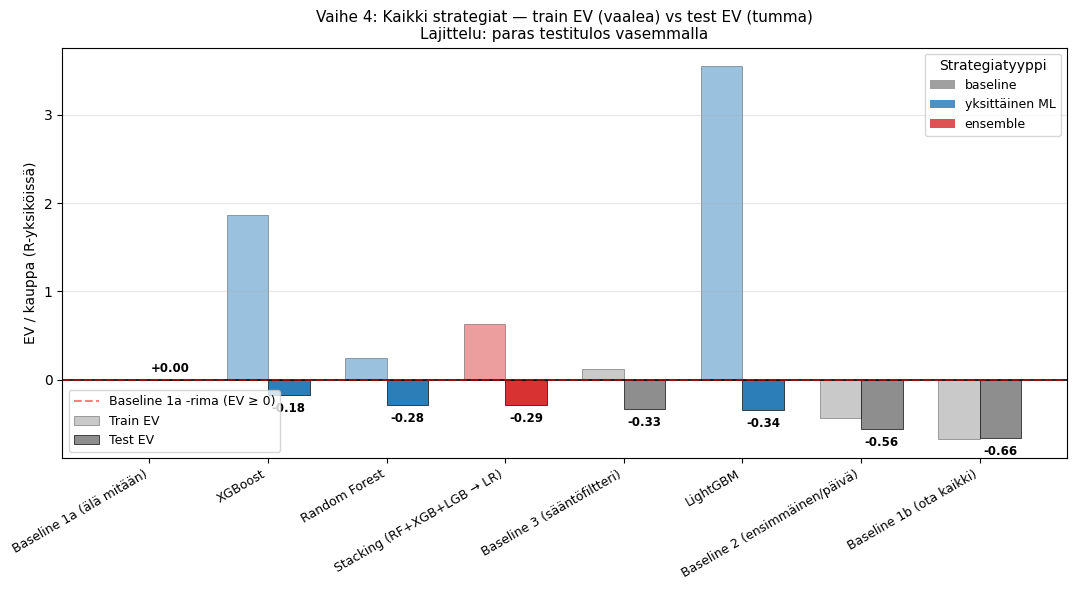

✓ Tallennettu reports/figures/vaihe4_vertailu_train_test_ev.png


In [47]:
# ============================================================
# Päägrafiikka: train EV vs test EV
# Visualisoi sekä järjestyksen että overfit-eron
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))

# Värit tyypin mukaan
color_map = {'baseline': '#888888', 'yksittäinen ML': '#1f77b4', 'ensemble': '#d62728'}
colors = [color_map[t] for t in all_results_sorted['tyyppi']]

x = np.arange(len(all_results_sorted))
width = 0.35

bars_train = ax.bar(x - width/2, all_results_sorted['train_ev'], width,
                     label='Train EV', color=colors, alpha=0.45, edgecolor='black', linewidth=0.5)
bars_test = ax.bar(x + width/2, all_results_sorted['test_ev'], width,
                    label='Test EV', color=colors, alpha=0.95, edgecolor='black', linewidth=0.5)

# Rima
ax.axhline(0, color='black', lw=1.2, ls='-')
ax.axhline(0, color='red', lw=1.5, ls='--', alpha=0.5, label='Baseline 1a -rima (EV ≥ 0)')

# Annotoinnit testitulosten päälle
for i, bar in enumerate(bars_test):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.05 if h >= 0 else -0.08),
            f'{h:+.2f}', ha='center', va='bottom' if h >= 0 else 'top', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_results_sorted['strategia'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('EV / kauppa (R-yksiköissä)')
ax.set_title('Vaihe 4: Kaikki strategiat — train EV (vaalea) vs test EV (tumma)\n'
             'Lajittelu: paras testitulos vasemmalla', fontsize=11)
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Erillinen legenda tyypille
from matplotlib.patches import Patch
type_legend = [Patch(facecolor=color_map[t], alpha=0.8, label=t) for t in ['baseline', 'yksittäinen ML', 'ensemble']]
ax2 = ax.twinx(); ax2.axis('off')
ax2.legend(handles=type_legend, loc='upper right', fontsize=9, title='Strategiatyyppi')

plt.tight_layout()
plt.savefig('../reports/figures/vaihe4_vertailu_train_test_ev.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Tallennettu reports/figures/vaihe4_vertailu_train_test_ev.png")

In [ ]:
# ============================================================
# Overfit-monotonia: mallin kapasiteetti vs train→test-ero
# Tämä on Löytö #25:n keskeisin visualisointi
# ============================================================
# Vain ML-strategiat ja Baseline 3 (jolla on rule-based "kapasiteetti")
ml_data = all_results[all_results['tyyppi'].isin(['baseline', 'yksittäinen ML', 'ensemble'])].copy()
ml_data = ml_data[ml_data['strategia'].isin([
    'Baseline 3 (sääntöfiltteri)', 'Random Forest', 'XGBoost', 'LightGBM',
    'Stacking (RF+XGB+LGB → LR)'
])].copy()

# Lisätään kapasiteetti-järjestys käsin (matalin → korkein)
capacity_order = {
    'Baseline 3 (sääntöfiltteri)': 1,
    'Random Forest':                2,
    'Stacking (RF+XGB+LGB → LR)':   3,
    'XGBoost':                      4,
    'LightGBM':                     5,
}
ml_data['capacity'] = ml_data['strategia'].map(capacity_order)
ml_data = ml_data.sort_values('capacity').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vasen: train EV vs test EV
ax = axes[0]
for i, row in ml_data.iterrows():
    ax.plot([row['train_ev'], row['test_ev']], [i, i], 'o-',
            color='steelblue', markersize=9, lw=2)
    ax.text(row['train_ev'], i + 0.13, f"train {row['train_ev']:+.2f}",
            fontsize=8, ha='center', color='steelblue')
    ax.text(row['test_ev'], i - 0.18, f"test {row['test_ev']:+.2f}",
            fontsize=8, ha='center', color='darkred', fontweight='bold')

ax.set_yticks(range(len(ml_data)))
ax.set_yticklabels(ml_data['strategia'])
ax.axvline(0, color='red', ls='--', alpha=0.6, label='EV = 0 -rima')
ax.set_xlabel('EV / kauppa (R)')
ax.set_title('Train EV → Test EV per strategia\n(järjestys: kapasiteetti nouseva)', fontsize=10)
ax.invert_yaxis()
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Oikea: kapasiteetti vs train→test-ero
ax = axes[1]
ax.plot(ml_data['capacity'], ml_data['train_test_diff'], 'o-',
        color='darkred', markersize=12, lw=2.5)
for i, row in ml_data.iterrows():
    ax.annotate(row['strategia'].replace(' (', '\n('),
                xy=(row['capacity'], row['train_test_diff']),
                xytext=(8, -5 if row['train_test_diff'] > -2 else 10),
                textcoords='offset points', fontsize=8.5)

ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Mallin kapasiteetti (kasvava →)')
ax.set_ylabel('Train→test ero (R/kauppa)')
ax.set_title('Löytö #25: Mallin kapasiteetti vs overfit-aste\n'
             'Monotonisesti laskeva — suurempi malli = pahempi overfit', fontsize=10)
ax.set_xticks(ml_data['capacity'])
ax.set_xticklabels(['Säännöt', 'RF', 'Stack', 'XGB', 'LGB'], fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/vaihe4_overfit_monotonia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Tallennettu reports/figures/vaihe4_overfit_monotonia.png")